In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("../data/Coursera.csv")

df.head()

,Course Name,University,Difficulty Level,Course Rating,Course URL,Course Description,Skills
0,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,Write a Full Length Feature Film Script In th...,Drama Comedy peering screenwriting film D...
1,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,"By the end of this guided project, you will be...",Finance business plan persona (user experien...
2,Silicon Thin Film Solar Cells,�cole Polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,This course consists of a general presentation...,chemistry physics Solar Energy film lambda...
3,Finance for Managers,IESE Business School,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis...
4,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,In this course you�ll learn how to effectively...,Data Analysis select (sql) database manageme...


In [4]:
df.shape

(3522, 7)

In [5]:
df.columns.tolist()

['Course Name',
 'University',
 'Difficulty Level',
 'Course Rating',
 'Course URL',
 'Course Description',
 'Skills']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3522 entries, 0 to 3521
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Course Name         3522 non-null   str  
 1   University          3522 non-null   str  
 2   Difficulty Level    3522 non-null   str  
 3   Course Rating       3522 non-null   str  
 4   Course URL          3522 non-null   str  
 5   Course Description  3522 non-null   str  
 6   Skills              3522 non-null   str  
dtypes: str(7)
memory usage: 192.7 KB


In [7]:
df.isnull().sum()

Course Name           0
University            0
Difficulty Level      0
Course Rating         0
Course URL            0
Course Description    0
Skills                0
dtype: int64

In [8]:
df["Difficulty Level"].value_counts()

Difficulty Level
Beginner          1444
Advanced          1005
Intermediate       837
Conversant         186
Not Calibrated      50
Name: count, dtype: int64

In [9]:
df["Course Rating"].describe()

count     3522
unique      31
top        4.7
freq       740
Name: Course Rating, dtype: object

In [10]:
df["Skills"].head(10)

0    Drama  Comedy  peering  screenwriting  film  D...
1    Finance  business plan  persona (user experien...
2    chemistry  physics  Solar Energy  film  lambda...
3    accounts receivable  dupont analysis  analysis...
4    Data Analysis  select (sql)  database manageme...
5    maintenance  test case  test automation  scree...
6    marketing plan  Planning  Marketing  consumpti...
7    inference  ml (programming language)  higher-o...
8    Planning  Peer Review  fundraising  strategic ...
9    Russian  market (economics)  tax exemption  co...
Name: Skills, dtype: str

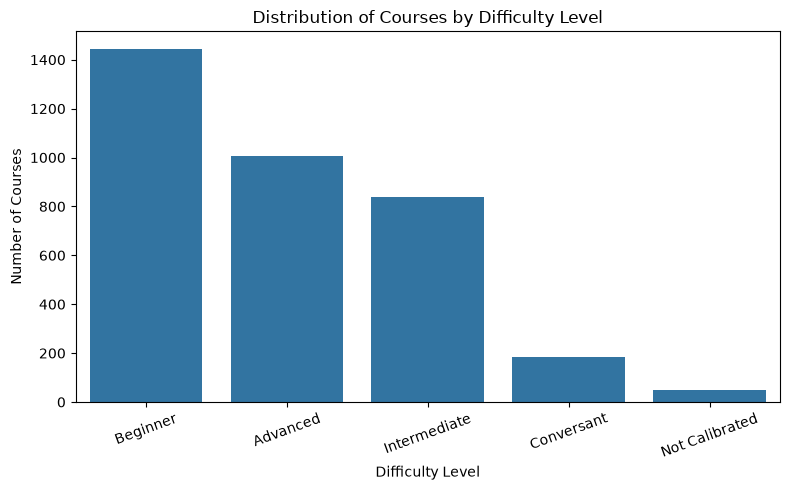

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Difficulty Level",
    order=df["Difficulty Level"].value_counts().index
)

plt.title("Distribution of Courses by Difficulty Level")
plt.xlabel("Difficulty Level")
plt.ylabel("Number of Courses")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

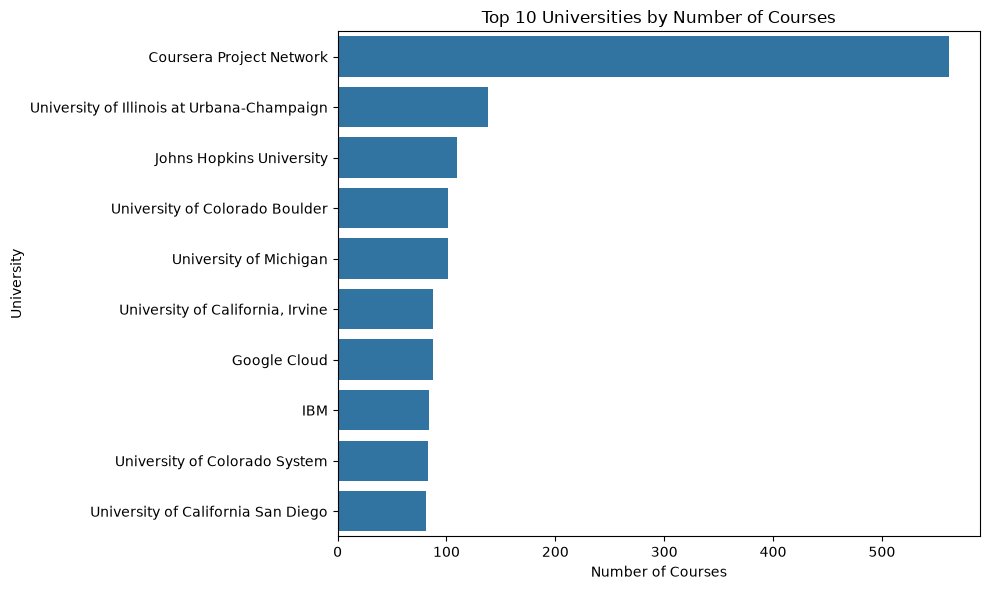

In [12]:
top_universities = df["University"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_universities.values,
    y=top_universities.index
)

plt.title("Top 10 Universities by Number of Courses")
plt.xlabel("Number of Courses")
plt.ylabel("University")
plt.tight_layout()
plt.show()

In [13]:
df["Course Rating"] = pd.to_numeric(
    df["Course Rating"],
    errors="coerce"
)

df["Course Rating"].isna().sum()

np.int64(82)

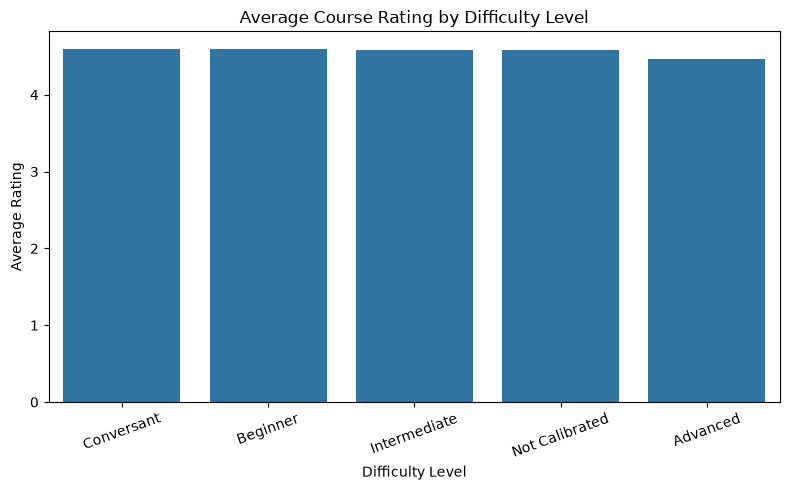

In [14]:
difficulty_rating = (
    df.groupby("Difficulty Level")["Course Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=difficulty_rating.index,
    y=difficulty_rating.values
)

plt.title("Average Course Rating by Difficulty Level")
plt.xlabel("Difficulty Level")
plt.ylabel("Average Rating")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [15]:
df[["Course Name", "Course Description", "Skills"]].head(10)

,Course Name,Course Description,Skills
0,Write A Feature Length Screenplay For Film Or ...,Write a Full Length Feature Film Script In th...,Drama Comedy peering screenwriting film D...
1,Business Strategy: Business Model Canvas Analy...,"By the end of this guided project, you will be...",Finance business plan persona (user experien...
2,Silicon Thin Film Solar Cells,This course consists of a general presentation...,chemistry physics Solar Energy film lambda...
3,Finance for Managers,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis...
4,Retrieve Data using Single-Table SQL Queries,In this course you�ll learn how to effectively...,Data Analysis select (sql) database manageme...
5,Building Test Automation Framework using Selen...,Selenium is one of the most widely used functi...,maintenance test case test automation scree...
6,Doing Business in China Capstone,Doing Business in China Capstone enables you t...,marketing plan Planning Marketing consumpti...
7,"Programming Languages, Part A",This course is an introduction to the basic co...,inference ml (programming language) higher-o...
8,The Roles and Responsibilities of Nonprofit Bo...,This course provides a more in-depth look at t...,Planning Peer Review fundraising strategic ...
9,Business Russian Communication. Part 3,Russian is considered to be one of the most di...,Russian market (economics) tax exemption co...


In [22]:
df["combined_features"] = (
    df["Course Name"].fillna("") + " " +
    df["Course Description"].fillna("") + " " +
    df["Skills"].fillna("")
)

df[["Course Name", "combined_features"]].head()

,Course Name,combined_features
0,Write A Feature Length Screenplay For Film Or ...,Write A Feature Length Screenplay For Film Or ...
1,Business Strategy: Business Model Canvas Analy...,Business Strategy: Business Model Canvas Analy...
2,Silicon Thin Film Solar Cells,Silicon Thin Film Solar Cells This course cons...
3,Finance for Managers,"Finance for Managers When it comes to numbers,..."
4,Retrieve Data using Single-Table SQL Queries,Retrieve Data using Single-Table SQL Queries I...


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df["combined_features"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (3522, 5000)


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (3522, 3522)


In [25]:
def recommend_courses(query, top_n=5):
    query_vector = tfidf.transform([query])

    similarity_scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    top_indices = similarity_scores.argsort()[-top_n:][::-1]

    recommendations = df.iloc[top_indices][
        [
            "Course Name",
            "University",
            "Difficulty Level",
            "Course Rating",
            "Course URL"
        ]
    ].copy()

    recommendations["Similarity Score"] = similarity_scores[top_indices]

    return recommendations

In [26]:
recommend_courses("Database Management Systems SQL", top_n=5)

,Course Name,University,Difficulty Level,Course Rating,Course URL,Similarity Score
1731,Advanced Relational Database and SQL,Coursera Project Network,Advanced,4.6,https://www.coursera.org/learn/Advanced-rdb-sql,0.621615
3390,Database Design with SQL Server Management Stu...,Coursera Project Network,Beginner,4.5,https://www.coursera.org/learn/database-design...,0.606782
1500,Intermediate Relational Database and SQL,Coursera Project Network,Advanced,4.4,https://www.coursera.org/learn/intermediate-rd...,0.600120
2835,Querying Databases Using SQL SELECT statement,Coursera Project Network,Advanced,4.6,https://www.coursera.org/learn/querying-databa...,0.583565
2872,Introduction to Structured Query Language (SQL),University of Michigan,Conversant,4.7,https://www.coursera.org/learn/intro-sql,0.577633


In [27]:
recommend_courses("Operating Systems", top_n=5)

,Course Name,University,Difficulty Level,Course Rating,Course URL,Similarity Score
3021,Operating Systems and You: Becoming a Power User,Google,Conversant,4.6,https://www.coursera.org/learn/os-power-user,0.487257
3196,Embedded Hardware and Operating Systems,EIT Digital,Advanced,3.9,https://www.coursera.org/learn/embedded-operat...,0.461715
1050,"Cybersecurity Roles, Processes & Operating Sys...",IBM,Beginner,4.5,https://www.coursera.org/learn/cybersecurity-r...,0.311452
1049,"Cybersecurity Roles, Processes & Operating Sys...",IBM,Beginner,4.5,https://www.coursera.org/learn/cybersecurity-r...,0.311452
3360,Capstone: Autonomous Runway Detection for IoT,EIT Digital,Advanced,4.5,https://www.coursera.org/learn/autonomous-runw...,0.294117
